## What is the most optimal skill to learn for Data Analysts?

#### Methology
1. Group skills to determine median salary and likelihood of being in posting
2. Visulaize median salary vs percent skill demand

In [38]:
# importing libraries

import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#data cleanup $ convert job skills column from a string to a list
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

In [39]:
df_DA_US=df_US = df[
    (df['job_title_short']=='Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

In [40]:
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_exploded=df_DA_US.explode('job_skills')
df_DA_US_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [41]:
df_DA_skills = df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})

DA_job_count = len(df_DA_US)

df_DA_skills['skills_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 5

df_DA_skills_high_demand = df_DA_skills[
    df_DA_skills['skills_percent'] > skill_percent
]

df_DA_skills_high_demand

,skill_count,median_salary,skills_percent
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


In [51]:
import ast

df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary

    for key, value in row_dict.items():

        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# remove duplicates
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['ssrs',
  'msaccess',
  'looker',
  'dax',
  'powerbi',
  'powerpoint',
  'excel',
  'qlik',
  'ms access',
  'sas',
  'cognos',
  'visio',
  'power bi',
  'sheets',
  'microstrategy',
  'outlook',
  'datarobot',
  'esquisse',
  'spss',
  'nuix',
  'tableau',
  'splunk',
  'word',
  'sharepoint',
  'sap',
  'ssis',
  'spreadsheet',
  'alteryx'],
 'programming': ['c',
  'matlab',
  'c++',
  'scala',
  'groovy',
  'perl',
  'clojure',
  'sql',
  'typescript',
  'fortran',
  'no-sql',
  'solidity',
  'lisp',
  'elixir',
  'mongo',
  'vba',
  'delphi',
  'nosql',
  'powershell',
  'sas',
  'kotlin',
  'objective-c',
  'dart',
  'mongodb',
  'haskell',
  'ruby',
  'r',
  'sass',
  'cobol',
  'rust',
  'go',
  'shell',
  'php',
  'visualbasic',
  'apl',
  'crystal',
  'f#',
  'vb.net',
  'golang',
  'bash',
  'lua',
  'css',
  't-sql',
  'julia',
  'java',
  'ocaml',
  'visual basic',
  'c#',
  'assembly',
  'python',
  'swift',
  'pascal',
  'javascript',
  'html',
  'erl

In [55]:
df_technology=pd.DataFrame(list(technology_dict.items()), columns=['technology','skills'])
df_technology=df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,ssrs
0,analyst_tools,msaccess
0,analyst_tools,looker
0,analyst_tools,dax
0,analyst_tools,powerbi
...,...,...
9,sync,microsoft teams
9,sync,unify
9,sync,ringcentral
9,sync,wire


In [57]:
df_plot=df_DA_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

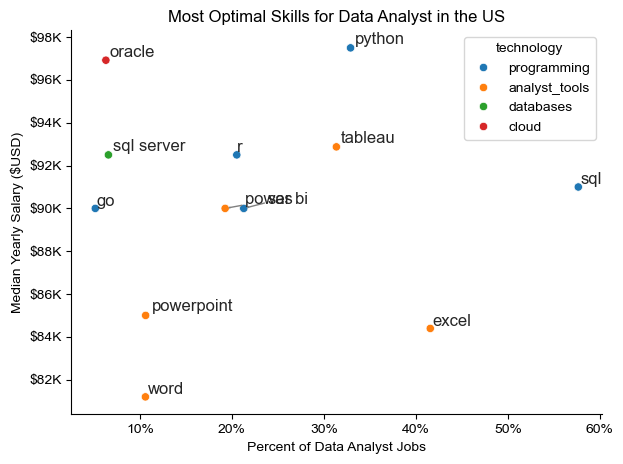

In [60]:
from adjustText import adjust_text
import matplotlib.pyplot as plt

#df_plot.plot(kind='scatter',x='skills_percent',y='median_salary')

sns.scatterplot(
    data=df_plot,
    x='skills_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

texts = []

for i, txt in enumerate(df_DA_skills_high_demand.index):
    texts.append(
        plt.text(
            df_DA_skills_high_demand['skills_percent'].iloc[i],
            df_DA_skills_high_demand['median_salary'].iloc[i],
            txt
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='grey', lw=1)
)

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0)
)

plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Most Optimal Skills for Data Analyst in the US')

plt.tight_layout()
plt.show()